# Exploratory Data Analysis — Craigslist Used Cars Dataset
**CT118-3-3 ODL | Assignment 1 — Task 2: Data Preparation**

Dataset: [Craigslist Used Cars (Kaggle)](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)


## Section 1 — Imports & Configuration

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── CONFIG ─────────────────────────────────────────────────────────────────
DATA_PATH   = 'dataset\\vehicles.csv' 
OUTPUT_DIR  = 'eda_outputs'   # plots are also saved here
SAMPLE_SIZE = None            # set e.g. 100_000 for a fast preview; None = full

os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=150)
    print(f'  [saved] {path}')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
print('Libraries loaded and config set.')

Libraries loaded and config set.


## Section 2 — Load Data & Basic Shape

In [4]:
df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE, low_memory=False)
print(f'Rows : {df.shape[0]:,}')
print(f'Cols : {df.shape[1]}')
print()
print('Column dtypes:')
print(df.dtypes.to_string())

Rows : 426,880
Cols : 26

Column dtypes:
id                int64
url              object
region           object
region_url       object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        object
description      object
county          float64
state            object
lat             float64
long            float64
posting_date     object


In [5]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

## Section 3 — Missing Values
Identify columns with null data and visualise the extent of missingness.

In [7]:
miss = (
    df.isnull().sum()
      .rename('missing')
      .to_frame()
      .assign(pct=lambda x: x['missing'] / len(df) * 100)
      .sort_values('pct', ascending=False)
)
print('Missing value summary:')
display(miss[miss['missing'] > 0])

Missing value summary:


,missing,pct
county,426880,100.00
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93


## Section 4 — Duplicate Rows

In [8]:
n_dup = df.duplicated().sum()
print(f'Exact duplicate rows : {n_dup:,}  ({n_dup/len(df)*100:.2f}%)')

Exact duplicate rows : 0  (0.00%)


## Section 5 — Descriptive Statistics (Numeric Columns)

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Numeric columns: {num_cols}')
df[num_cols].describe().T

Numeric columns: ['id', 'price', 'year', 'odometer', 'county', 'lat', 'long']


,count,mean,std,min,25%,50%,75%,max
id,426880.00,7311486634.22,4473170.41,7207408119.00,7308143339.25,7312620821.00,7315253543.50,7317101084.00
price,426880.00,75199.03,12182282.17,0.00,5900.00,13950.00,26485.75,3736928711.00
year,425675.00,2011.24,9.45,1900.00,2008.00,2013.00,2017.00,2022.00
odometer,422480.00,98043.33,213881.50,0.00,37704.00,85548.00,133542.50,10000000.00
county,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,420331.00,38.49,5.84,-84.12,34.60,39.15,42.40,82.39
long,420331.00,-94.75,18.37,-159.83,-111.94,-88.43,-80.83,173.89


## Section 6 — Target Variable: `price`
Examine the distribution of the target variable, including skewness and outliers.

In [10]:
price_raw = df['price'].dropna()
print(f'Count non-null : {len(price_raw):,}')
print(f'Min            : ${price_raw.min():,.0f}')
print(f'Max            : ${price_raw.max():,.0f}')
print(f'Mean           : ${price_raw.mean():,.0f}')
print(f'Median         : ${price_raw.median():,.0f}')
print(f'Std Dev        : ${price_raw.std():,.0f}')
print(f'Skewness       : {price_raw.skew():.3f}')

Count non-null : 426,880
Min            : $0
Max            : $3,736,928,711
Mean           : $75,199
Median         : $13,950
Std Dev        : $12,182,282
Skewness       : 254.407


## Section 7 — Outlier Detection (IQR Method)
Use the interquartile range (IQR) to flag statistical outliers in key numeric columns.

In [11]:
def iqr_outliers(series, name):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lo) | (s > hi)).sum()
    print(f'{name:15s} | Q1={Q1:,.1f}  Q3={Q3:,.1f}  IQR={IQR:,.1f} '
          f'| fence=[{lo:,.1f}, {hi:,.1f}] | outliers={n_out:,} ({n_out/len(s)*100:.1f}%)')

for col in ['price', 'year', 'odometer']:
    if col in df.columns:
        iqr_outliers(df[col], col)

price           | Q1=5,900.0  Q3=26,485.8  IQR=20,585.8 | fence=[-24,978.6, 57,364.4] | outliers=8,177 (1.9%)
year            | Q1=2,008.0  Q3=2,017.0  IQR=9.0 | fence=[1,994.5, 2,030.5] | outliers=15,896 (3.7%)
odometer        | Q1=37,704.0  Q3=133,542.5  IQR=95,838.5 | fence=[-106,053.8, 277,300.2] | outliers=4,385 (1.0%)


## Section 8 — Categorical Feature Analysis

In [12]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print()
for col in cat_cols:
    top_val = df[col].value_counts().head(1)
    print(f'  {col:20s} | unique={df[col].nunique():5d} | top="{top_val.index[0]}" ({top_val.iloc[0]:,})')

Categorical columns (19): ['url', 'region', 'region_url', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'state', 'posting_date']

  url                  | unique=426880 | top="https://wyoming.craigslist.org/ctd/d/atlanta-2017-genesis-g80-38-sedan-4d/7301949724.html" (1)
  region               | unique=  404 | top="columbus" (3,608)
  region_url           | unique=  413 | top="https://spokane.craigslist.org" (2,988)
  manufacturer         | unique=   42 | top="ford" (70,985)
  model                | unique=29667 | top="f-150" (8,009)
  condition            | unique=    6 | top="good" (121,456)
  cylinders            | unique=    8 | top="6 cylinders" (94,169)
  fuel                 | unique=    5 | top="gas" (356,209)
  title_status         | unique=    6 | top="clean" (405,117)
  transmission         | unique=    3 | top="automatic" (336,524)
  VIN                  | 

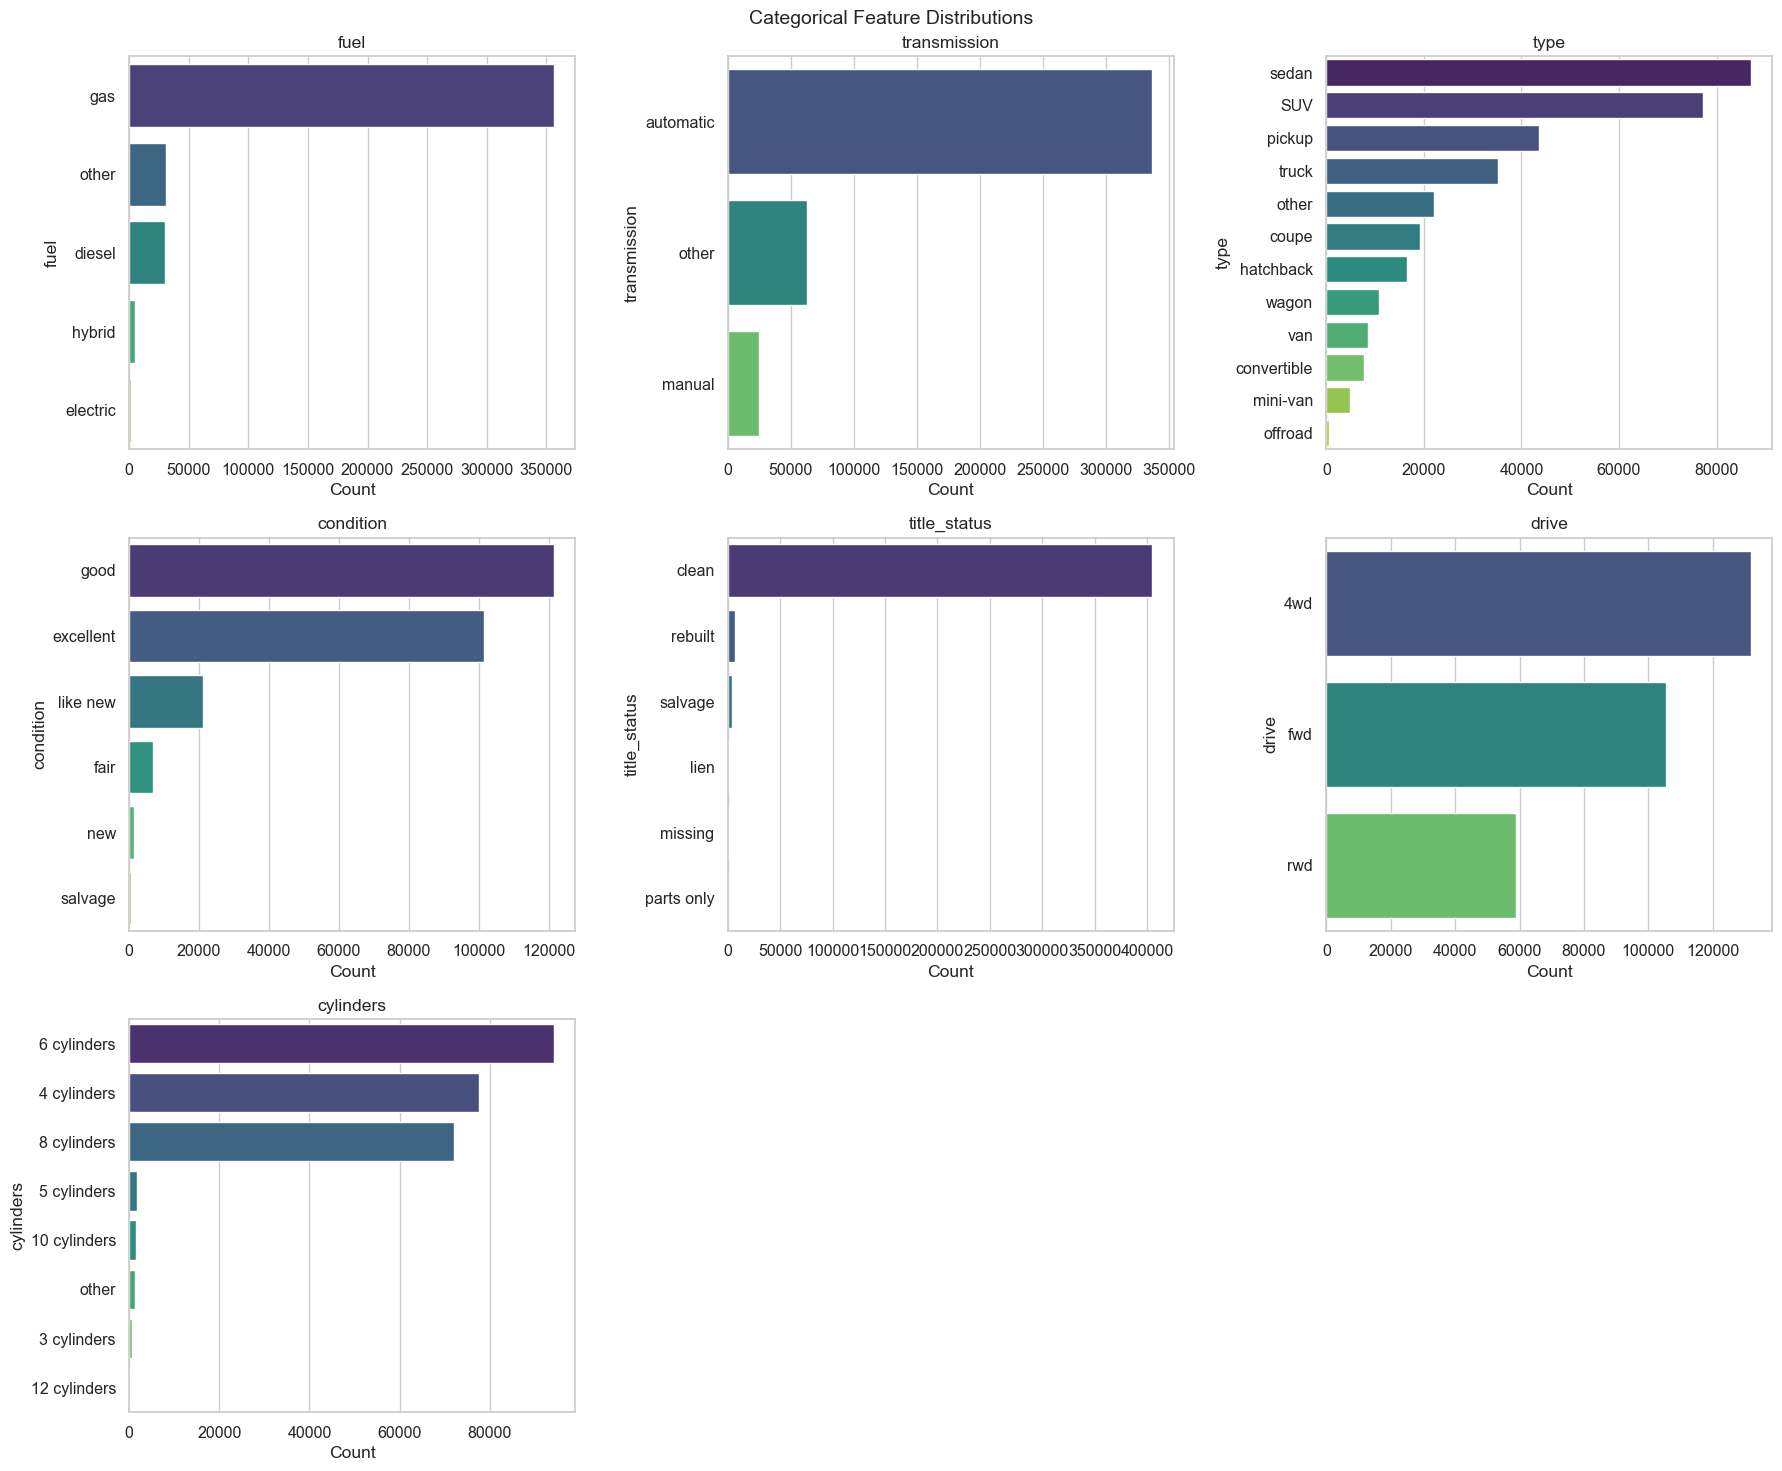

In [13]:
plot_cats = [c for c in ['fuel','transmission','type','condition',
                         'title_status','drive','cylinders'] if c in df.columns]
n_rows_g = (len(plot_cats)+2)//3
fig, axes = plt.subplots(n_rows_g, 3, figsize=(18, 5*n_rows_g))
axes = axes.flatten()
for ax, col in zip(axes, plot_cats):
    vc = df[col].value_counts().head(12)
    sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='viridis')
    ax.set_title(col); ax.set_xlabel('Count')
for ax in axes[len(plot_cats):]: ax.set_visible(False)
fig.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

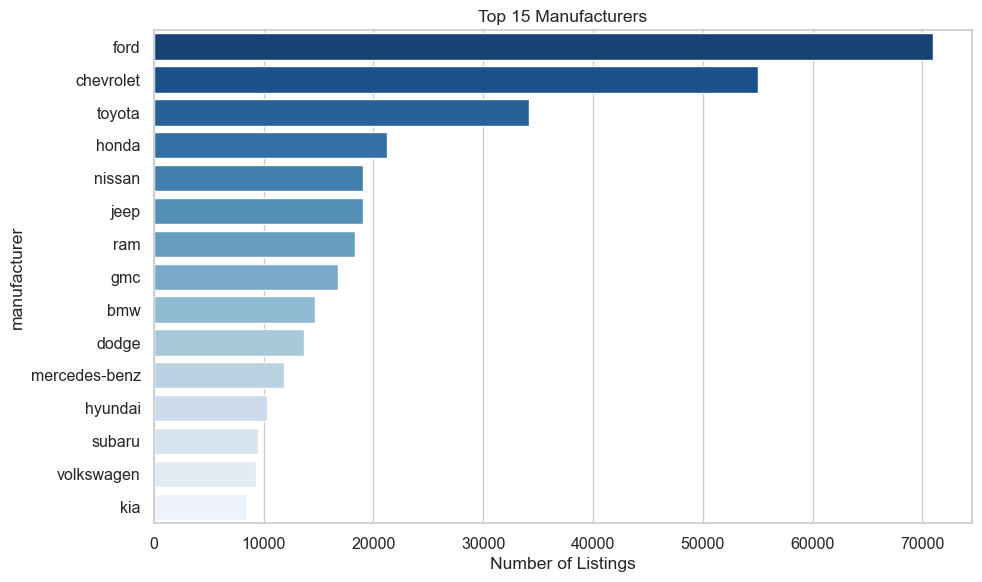

In [14]:
if 'manufacturer' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    top_make = df['manufacturer'].value_counts().head(15)
    sns.barplot(x=top_make.values, y=top_make.index, palette='Blues_r', ax=ax)
    ax.set_title('Top 15 Manufacturers'); ax.set_xlabel('Number of Listings')
    plt.tight_layout()
    plt.show()

## Section 9 — Correlation Heatmap

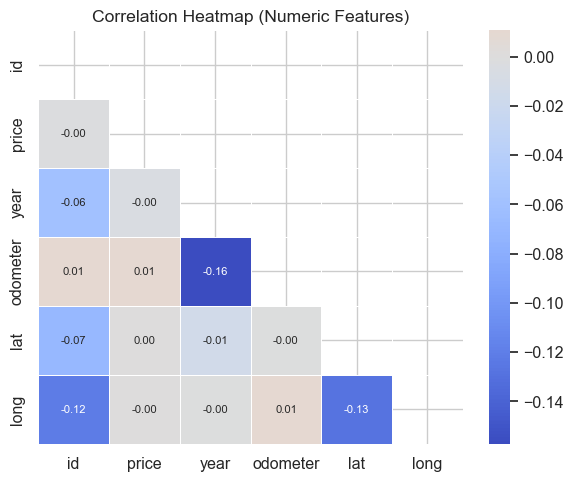

In [15]:
corr_cols = [c for c in num_cols if df[c].nunique() > 1]
corr_matrix = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(max(6, len(corr_cols)), max(5, len(corr_cols)-1)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

## Section 10 — Noise & Data Quality Report


In [16]:
print('=' * 65)
print('  DATA QUALITY REPORT')
print('=' * 65)

total_cells   = df.size
total_missing = df.isnull().sum().sum()

if 'price' in df.columns:
    zp = (df['price'] == 0).sum()
    ep = (df['price'] > 500_000).sum()
    print(f'  price == 0                 : {zp:,} rows ({zp/len(df)*100:.1f}%)')
    print(f'  price > $500,000 (extreme) : {ep:,} rows')

if 'year' in df.columns:
    fy = (df['year'] > 2025).sum()
    print(f'  year > 2025 (bad)          : {fy:,} rows')

if 'odometer' in df.columns:
    zo = (df['odometer'] == 0).sum()
    print(f'  odometer == 0              : {zo:,} rows')

print(f'  Exact duplicate rows       : {n_dup:,}')
print(f'  Total missing cells        : {total_missing:,} / {total_cells:,} ({total_missing/total_cells*100:.2f}%)')

drop_candidates   = miss[miss['pct'] > 50].index.tolist()
impute_candidates = miss[(miss['pct'] > 0) & (miss['pct'] <= 50)].index.tolist()
print()
print(f'  Columns >50% missing  -> DROP   : {drop_candidates}')
print(f'  Columns 1-50% missing -> IMPUTE : {impute_candidates}')
print('=' * 65)

  DATA QUALITY REPORT
  price == 0                 : 32,895 rows (7.7%)
  price > $500,000 (extreme) : 68 rows
  year > 2025 (bad)          : 0 rows
  odometer == 0              : 1,965 rows
  Exact duplicate rows       : 0
  Total missing cells        : 1,655,336 / 11,098,880 (14.91%)

  Columns >50% missing  -> DROP   : ['county', 'size']
  Columns 1-50% missing -> IMPUTE : ['cylinders', 'condition', 'VIN', 'drive', 'paint_color', 'type', 'manufacturer', 'title_status', 'lat', 'long', 'model', 'odometer', 'fuel', 'transmission', 'year', 'description', 'posting_date', 'image_url']


---
## Next Steps (Assignment 1 → Assignment 2)
Based on the EDA above:
1. **Drop** columns with >50% missing values (e.g. `county`, `size`)
2. **Impute** moderate-missing columns: numeric → median; categorical → mode or `'unknown'`
3. **Remove outliers**: filter `price` to [500, 100,000], `odometer` to [0, 400,000]
4. **Encode** categoricals: `LabelEncoder` or `pd.get_dummies` for deep learning input
5. **Log-transform** `price` to reduce skewness before model training
6. **Feature engineer**: car age = `2025 - year`; high-mileage flag, etc.